# Week 09 — Home exercise 4: One function, any country

**Solution proposal.**

The function shape worth knowing by heart: a table in, a name in, a finished figure out.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

co2 = pd.read_csv("../data/co2_emissions.csv")
info = pd.read_csv("../data/country_info.csv")

panel = co2.merge(info[["code", "region"]], on="code", how="left", validate="many_to_one")
panel = panel[panel["region"] != "Aggregates"].dropna(subset=["co2_total"])
panel["co2_pc"] = panel["co2_total"] * 1_000_000 / panel["population"]

print(panel.shape, "|", panel["country"].nunique(), "countries")

(4872, 13) | 203 countries


Where the reference figure comes from, so that the number in the function is not a magic constant
somebody has to take on trust:

In [2]:
year_2023 = panel[panel["year"] == 2023]
world_pc = year_2023["co2_total"].sum() * 1_000_000 / year_2023["population"].sum()

print("world CO₂ per person, 2023:", round(world_pc, 2), "tonnes")
print("countries above it:", (year_2023["co2_pc"] > world_pc).sum(), "of", len(year_2023))

world CO₂ per person, 2023: 4.68 tonnes
countries above it: 56 of 203


4.68 tonnes, and **56 of 203 countries are above it** — which is already the most interesting thing in
this exercise. The world average is not the middle of the countries; it is a population-weighted figure
that most countries sit below.

## The function

In [3]:
def plot_country(data, country, reference=4.68):
    """
    Draw CO2 emissions per person over time for one country.

    Parameters
    ----------
    data : DataFrame
        Panel with columns "country", "year" and "co2_pc".
    country : str
        Name of the country to draw. Must appear in data["country"].
    reference : float, optional
        Level at which to draw a horizontal reference line, in tonnes per
        person. Defaults to the 2023 world figure of 4.68.

    Returns
    -------
    Figure
        The finished figure.

    Raises
    ------
    ValueError
        If country is not one of the countries in data.
    """
    if country not in data["country"].unique():
        raise ValueError(f"no country called '{country}' in this table")

    rows = data[data["country"] == country].sort_values("year")

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(rows["year"], rows["co2_pc"], linewidth=2)

    ax.axhline(reference, color="gray", linestyle="--",
               label=f"world average, 2023 ({reference} t)")

    ax.set_xlabel("Year")
    ax.set_ylabel("CO₂ per person, tonnes")
    ax.set_title(f"{country}: CO₂ emissions per person")
    ax.set_ylim(0, None)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    return fig

## Demonstrating it

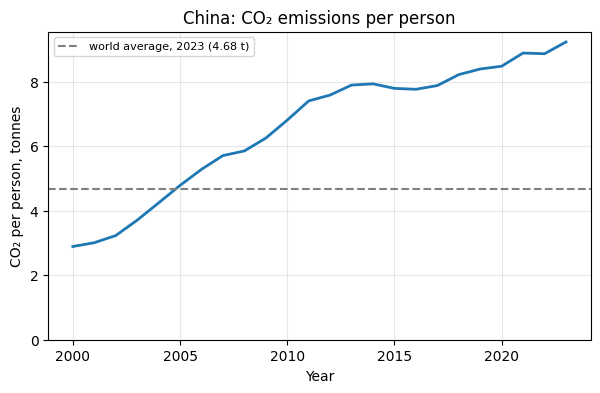

In [4]:
fig = plot_country(panel, "China")

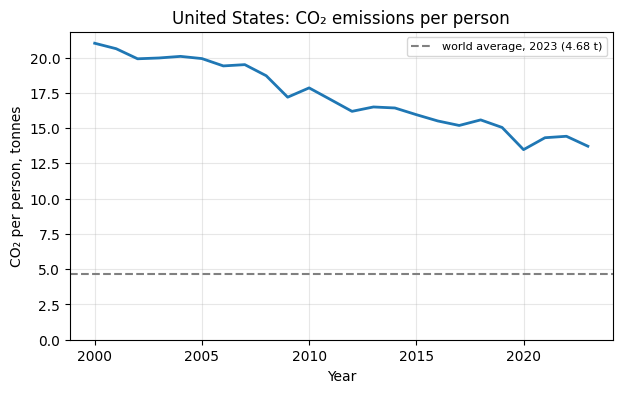

In [5]:
fig = plot_country(panel, "United States")

In [6]:
try:
    plot_country(panel, "Yugoslavia")
except ValueError as error:
    print(type(error).__name__, "-", error)

ValueError - no country called 'Yugoslavia' in this table


## What the two figures show together

Read separately, each is unremarkable. China rose from 2.9 tonnes per person in 2000 to 9.2 in 2023 and
crossed the world average in 2005. The United States fell from 21.0 to 13.7 over the same
period, and stayed above the world average throughout.

Read together they say something neither says alone: **the two lines converged, and they converged
because one of them rose.** In 2000 an American emitted about seven times what a Chinese person did; in
2023 it was less than one and a half times. The gap closed by China's rise far more than by America's
fall.

Two things a reader would miss with only one of the figures:

- **With only China**, the rise looks like a national story about industrialization. Against the United
  States it is visibly a *convergence*, and the natural next question is what the level converges to.
- **With only the United States**, the fall looks like progress toward the world average. It is
  progress, and it happened while the world average itself was rising to meet it — so the distance
  closed from both ends and the figure gives no way to tell how much came from which.

And the thing both figures hide: this is emissions **per person**, and China has more than four times
the population. On totals the two lines do not converge at all.

> 💡 **Tip:** Two figures drawn by the same function are directly comparable, because every choice —
axis limits, line width, the reference line, the fact the y-axis starts at zero — is made in one place.
Two figures drawn by two copied cells are comparable only if you remember to keep them in step, and you
will not.

### Things worth noticing

- **`ax.set_ylim(0, None)`** is the honest default for a quantity that cannot be negative. Without it,
  matplotlib zooms to the data and the American decline from 21 to 13.7 fills the whole figure, which
  makes a 35% fall look like a collapse. `None` means "leave the top to matplotlib".
- **The reference is a default argument, not a constant in the body.** `plot_country(panel, "India",
  reference=2.0)` now works with no edit to the function, and the number appears in the signature where
  a reader will find it.
- **The guard uses the same value the error message prints.** `f"no country called '{country}'"` tells
  the caller exactly what they typed, which is the difference between a useful error and an annoying
  one — most failures here are a spelling, and seeing your own spelling quoted back is usually enough.

### What this notebook does NOT do

- **The reference line is a 2023 figure drawn across all 24 years.** It is a fixed benchmark, not the
  world average of each year, and the figure does not say so beyond the legend. Drawing the world
  average as a second *line* would be more honest and would need a second series passed in.
- **It never checks that the country has data for every year.** A country with a gap gets a broken line
  and no comment; a country with two observations gets a straight line between them, which is the trap
  from the lecture, unguarded.
- **It cannot draw two countries on one figure**, which is the comparison the discussion above is
  actually making — the reader has to do it by scrolling. A version taking a *list* of countries would
  be a better function, and is a small change.